#CELL 1
# Workforce360 — Employee Attrition Prediction

This notebook trains and evaluates candidate machine-learning models that estimate observed employee attrition risk using the IBM HR Analytics portfolio dataset.

## Models Compared

- Logistic Regression
- Random Forest
- XGBoost

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

> **Responsible-use note:** The model is a portfolio decision-support demonstration. It must not be used to make automated employment, compensation, promotion, or termination decisions.

In [1]:
#CELL 2
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.load import load_raw_ibm_hr
from src.data.preprocess import clean_hr_data
from src.modeling.attrition import (
    prepare_attrition_data,
    save_attrition_model,
    select_best_model,
    split_attrition_data,
    train_attrition_models,
)

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

In [2]:
#CELL 3
raw_df = load_raw_ibm_hr()
df = clean_hr_data(raw_df)

X, y = prepare_attrition_data(df)

X_train, X_test, y_train, y_test = split_attrition_data(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print(f"Dataset rows: {len(df)}")
print(f"Feature columns: {X.shape[1]}")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Overall attrition rate: {y.mean():.2%}")

Dataset rows: 1470
Feature columns: 27
Training rows: 1176
Test rows: 294
Overall attrition rate: 16.12%


In [3]:
#CELL 4
fitted_models, comparison_df, detailed_metrics = train_attrition_models(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)

comparison_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.7687,0.3765,0.6809,0.4848,0.8144
1,Random Forest,0.8299,0.4651,0.4255,0.4444,0.8021
2,XGBoost,0.8265,0.4524,0.4043,0.4270,0.8006


In [4]:
#CELL 5
best_model_name, best_model = select_best_model(
    fitted_models=fitted_models,
    comparison_df=comparison_df,
)

model_path, metadata_path = save_attrition_model(
    model=best_model,
    model_name=best_model_name,
    metrics=detailed_metrics[best_model_name],
)

print(f"Selected model: {best_model_name}")
print(f"Model saved to: {model_path}")
print(f"Metadata saved to: {metadata_path}")

Selected model: Logistic Regression
Model saved to: C:\Users\Anvesha Garg\Desktop\workforce360\workforce360\models\attrition_model.joblib
Metadata saved to: C:\Users\Anvesha Garg\Desktop\workforce360\workforce360\models\attrition_model_metadata.json


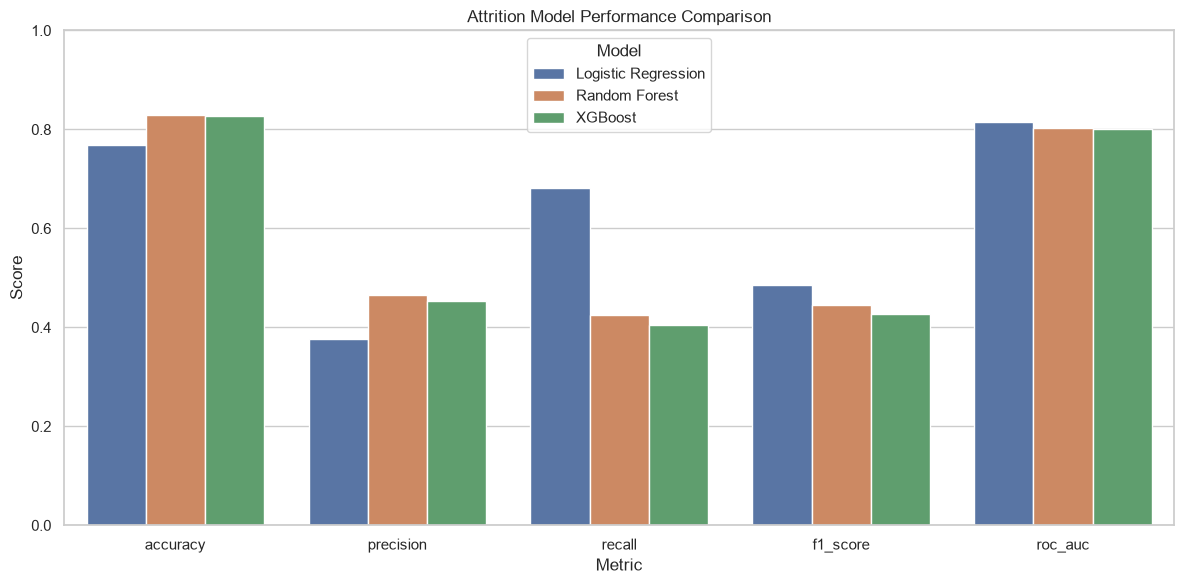

In [5]:
#CELL 6
plot_data = comparison_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="metric",
    y="score",
    hue="model",
)

plt.title("Attrition Model Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

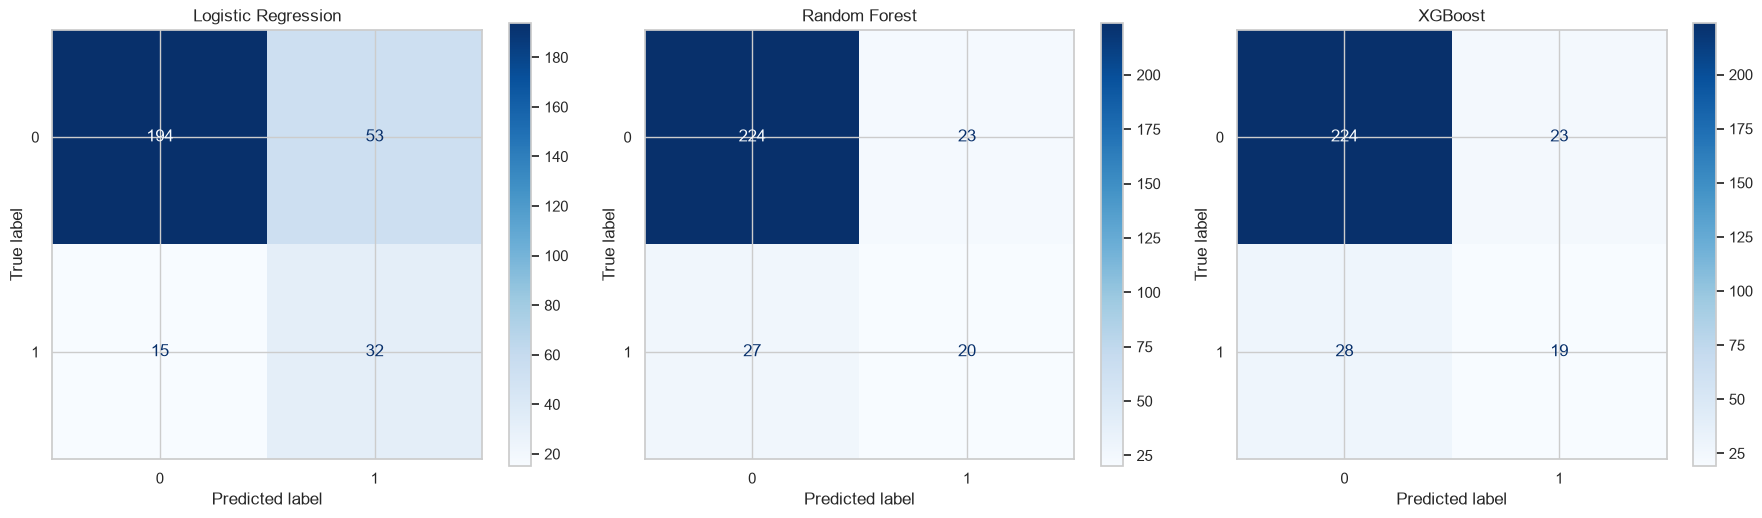

In [6]:
#CELL 7
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (model_name, model) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues",
        ax=axis,
    )
    axis.set_title(model_name)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

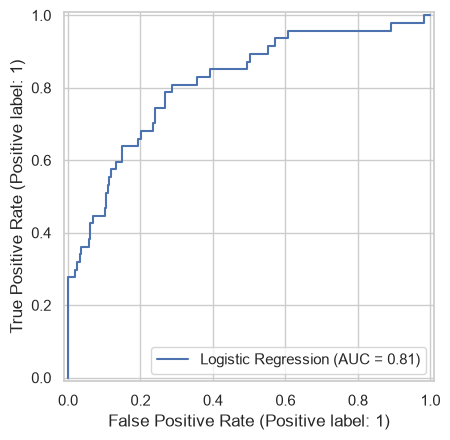

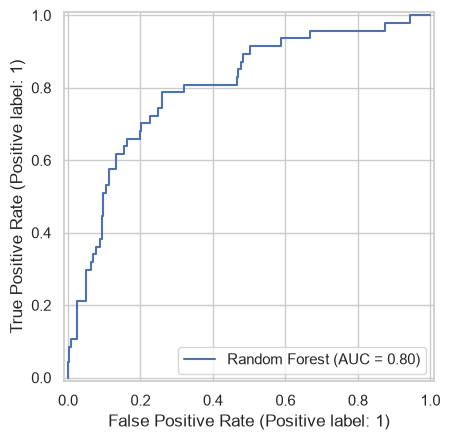

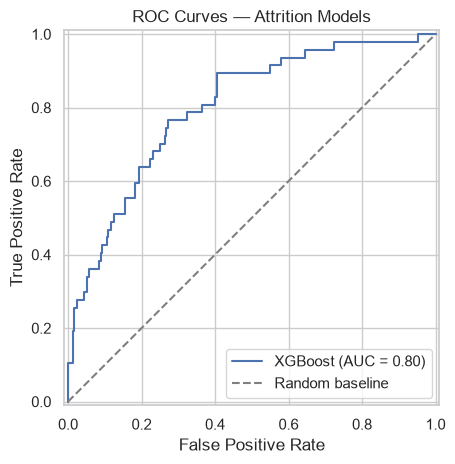

In [7]:
#CELL 8
plt.figure(figsize=(8, 6))

for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.title("ROC Curves — Attrition Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

#CELL 9
## Model Selection

The candidate models were ranked by:

1. ROC-AUC
2. F1-score as the tie-breaker

### Selected Model

**Logistic Regression** was selected because it produced the highest ROC-AUC and F1-score on the held-out test set.

| Metric | Logistic Regression |
|---|---:|
| Accuracy | 0.7687 |
| Precision | 0.3765 |
| Recall | 0.6809 |
| F1-score | 0.4848 |
| ROC-AUC | 0.8144 |

### Interpretation

- The model provides a probability-based attrition-risk signal for HR decision support.
- At a threshold of 0.50, the model identified approximately 68% of observed attrition cases in the held-out set.
- Precision was lower, meaning some employees marked as high risk did not attrite in the dataset.
- Therefore, predicted risk must be used only to prioritize human-led investigation and support—not to make automated employment decisions.